# BUSINESS SALES PERFORMANCE ANALYTICS

## Task 1 | Future Interns - Data Science & Analytics Internship (2026)

### Project Overview
This project focuses on analyzing real-world transactional data to evaluate business performance, identify key revenue drivers, and provide strategic recommendations. The goal is to transform raw sales data into actionable business intelligence that can help stakeholders optimize operations and drive growth.

### Dataset Description
The analysis is conducted using the Online Retail Dataset, which contains all transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based, non-store online retail business.

### Objectives & Methodology
The workflow for this project involves:

- Data Cleaning: Handling missing values (specifically in CustomerID), removing duplicates, and filtering out cancellations or data anomalies.
- Feature Engineering: Calculating total sales per line item and extracting time-based features (Month, Day, Hour) from the InvoiceDate.
- Exploratory Data Analysis (EDA): Visualizing trends and distributions to understand the business landscape.
- Reporting: Building a professional dashboard and drafting data-driven recommendations.

### Research Questions
To guide the analysis, this project seeks to answer the following key questions:

- Revenue Drivers: Which products generate the most revenue and have the highest sales volume?
- Temporal Trends: How do sales and revenue fluctuate over time? Are there specific months or days with significant peaks?
- Geographic Performance: Which countries/regions are the most profitable, and where is the strongest customer base located?
- Customer Insights: What is the average order value, and how does customer distribution impact total sales?
- Strategic Focus: Based on the data, where should the business focus its marketing or inventory efforts to accelerate growth?

## DATA PREPROCESSING

In [201]:
import pandas as pd
import numpy as np

In [202]:
# load the data 
 
data = pd.read_csv('data.csv', encoding='ISO-8859-1')

In [203]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [204]:
data.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


The dataset provides details of retail operations by tracking specific product sales, pricing, and customers

In [205]:
data.shape

(541909, 8)

The dataset contains 541 909 row entries and 8 column attributes.

In [206]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


On average, each transaction row consists of 9.5 units at a price of £4.60 per item. We observe some significant anomalies including negative values (min -80,995 quantity and -£11,062 price) which will have to be properly investigated and corrected if needed when cleaning.

## DATA CLEANING

In [207]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


We see already that there are some missing values and that CustomerID should be a string instead as it is an identifier and therefore categorical data.

In [208]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Description contains 1454 missing entries and CustomerID 135 080 missing entries. We check to see the percentage of missing values.

In [209]:
null_percentage = (data.isnull().sum() / len(data)) * 100

print(null_percentage.round(2))

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


Less than 1% of data is missing from the Description column so we can remove these entries from the dataset. However the percentage of missing CustomerID values is 24.93% which is much larger than our cut off of 5%, we will need to find a way to impute these values.

In [210]:
# dropping the rows with missing values in Description
data = data.dropna(subset=['Description'])
data.shape

(540455, 8)

Dropped 1454 rows

Since CustomerID is categorical data, we convert the datatype to a string and replace all the missing values with 'Unknown'.

In [211]:
data['CustomerID'] = data['CustomerID'].astype('Int64').astype(str)
data['CustomerID'] = data['CustomerID'].fillna('Unknown')

In [212]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [213]:
# check for duplicates

data.duplicated().sum()

5268

In [214]:
duplicates = data[data.duplicated()]
print(duplicates.head())

    InvoiceNo StockCode                        Description  Quantity  \
517    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
527    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
555    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   

         InvoiceDate  UnitPrice CustomerID         Country  
517  12/1/2010 11:45       1.25      17908  United Kingdom  
527  12/1/2010 11:45       2.10      17908  United Kingdom  
537  12/1/2010 11:45       2.95      17908  United Kingdom  
539  12/1/2010 11:45       4.95      17908  United Kingdom  
555  12/1/2010 11:49       2.95      17920  United Kingdom  


There are 5268 exact duplicate rows. We need to remove these to avoid double counting sales.

In [215]:
# keeps the first occurrence
data = data.drop_duplicates()
data.duplicated().sum()

0

Now that the duplicates have been removed we check for outliers.

In [216]:
kurtosis_values = data.select_dtypes(include=['number']).kurt()

print("Kurtosis values:")
print(kurtosis_values)

Kurtosis values:
Quantity     119121.326173
UnitPrice     58275.430805
dtype: float64


Kurtosis is unnaturally high for the 'Quantity' and 'UnitPrice' columns, which may indicate the presence of outliers. We should investigate these columns further to understand the distribution of values and identify any potential outliers that could be affecting our analysis.

In [217]:
# use IQR to identify outliers

Q1_qty = data['Quantity'].quantile(0.25)
Q3_qty = data['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lower_qty = Q1_qty - 1.5 * IQR_qty
upper_qty = Q3_qty + 1.5 * IQR_qty

outliers = data[(data['Quantity'] < lower_qty) | (data['Quantity'] > upper_qty)]
print(outliers)

       InvoiceNo StockCode                         Description  Quantity  \
9         536367     84879       ASSORTED COLOUR BIRD ORNAMENT        32   
26        536370     22728           ALARM CLOCK BAKELIKE PINK        24   
27        536370     22727           ALARM CLOCK BAKELIKE RED         24   
30        536370     21883                    STARS GIFT TAPE         24   
31        536370     10002         INFLATABLE POLITICAL GLOBE         48   
...          ...       ...                                 ...       ...   
541876    581585     84945  MULTI COLOUR SILVER T-LIGHT HOLDER        24   
541882    581585     21916     SET 12 RETRO WHITE CHALK STICKS        24   
541883    581585     84692         BOX OF 24 COCKTAIL PARASOLS        25   
541891    581586     23275    SET OF 3 HANGING OWLS OLLIE BEAK        24   
541892    581586     21217       RED RETROSPOT ROUND CAKE TINS        24   

            InvoiceDate  UnitPrice CustomerID         Country  
9        12/1/2010 8:34

In [218]:
Q1_price = data['UnitPrice'].quantile(0.25)
Q3_price = data['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

outliers_price = data[(data['UnitPrice'] < lower_price) | (data['UnitPrice'] > upper_price)]
print(outliers_price)

       InvoiceNo StockCode                      Description  Quantity  \
16        536367     22622   BOX OF VINTAGE ALPHABET BLOCKS         2   
45        536370      POST                          POSTAGE         3   
65        536374     21258       VICTORIAN SEWING BOX LARGE        32   
141      C536379         D                         Discount        -1   
151       536382     22839  3 TIER CAKE TIN GREEN AND CREAM         2   
...          ...       ...                              ...       ...   
541768    581578      POST                          POSTAGE         3   
541786    581578     22622   BOX OF VINTAGE ALPHABET BLOCKS         6   
541831    581579     22941     CHRISTMAS LIGHTS 10 REINDEER         4   
541849    581580     22894    TABLECLOTH RED APPLES DESIGN          2   
541892    581586     21217    RED RETROSPOT ROUND CAKE TINS        24   

            InvoiceDate  UnitPrice CustomerID         Country  
16       12/1/2010 8:34       9.95      13047  United Kingd

While IQR is an aggressive filtering method, I will use it here to remove extreme anomalies and bulk-order outliers that would otherwise skew the averages. This ensures that the subsequent visualizations reflect the behavior of the typical retail customer rather than system errors or rare wholesale transactions.

In [219]:
data = data[
    (data['Quantity'] >= lower_qty) & (data['Quantity'] <= upper_qty) &
    (data['UnitPrice'] >= lower_price) & (data['UnitPrice'] <= upper_price)
]
print(data.shape)

(438333, 8)


In [220]:
# Remove negative quantities (returns) and zero-priced items
data = data[data['Quantity'] > 0]
data = data[data['UnitPrice'] > 0]

In [221]:
# Standardise column names
data.columns = ['invoice_no', 'stock_code', 'product_description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']

# Convert invoice_date to datetime
data['invoice_date'] = pd.to_datetime(data['invoice_date'])

# Extract time features before dropping invoice_date
data['year'] = data['invoice_date'].dt.year
data['month'] = data['invoice_date'].dt.month
data['day_of_week'] = data['invoice_date'].dt.day_name()
data['hour'] = data['invoice_date'].dt.hour

# Drop invoice_date — all useful time info has been extracted
data = data.drop(columns=['invoice_date'])

# Count unique customers
unique_customers = data[data['customer_id'] != 'Unknown']['customer_id'].nunique()
total_customers_incl_unknown = data['customer_id'].nunique()
print(f"Unique identified customers: {unique_customers}")
print(f"Total unique customer IDs (incl. Unknown): {total_customers_incl_unknown}")

data.head()

Unique identified customers: 4166
Total unique customer IDs (incl. Unknown): 4166


,invoice_no,stock_code,product_description,quantity,unit_price,customer_id,country,year,month,day_of_week,hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850,United Kingdom,2010,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850,United Kingdom,2010,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850,United Kingdom,2010,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850,United Kingdom,2010,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850,United Kingdom,2010,12,Wednesday,8


The dataset now has `invoice_no` removed as it was a transaction-level identifier with no analytical value. Time features (`year`, `month`, `day_of_week`, `hour`) have been extracted from `invoice_date` before dropping it, enabling richer temporal analysis. The unique customer count (4,165 identified customers) gives us a clear picture of the customer base size.

In [222]:
data.to_csv('data_cleaned.csv', index=False)

## DATA ANALYSIS AND EXPLORATION

In [223]:
import pandas as pd 

data = pd.read_csv('data_cleaned.csv')
data.head()

,invoice_no,stock_code,product_description,quantity,unit_price,customer_id,country,year,month,day_of_week,hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,2010,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,2010,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,2010,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,2010,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,2010,12,Wednesday,8


In [224]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# custom colour palette 
blue = "#0077B6"  
green = "#2ECC71"

my_palette = [blue, green]
sns.set_palette(my_palette)

Create a total_revenue column for better sales analysis

In [225]:
data['total_revenue'] = data['quantity'] * data['unit_price']
data.describe()

,invoice_no,quantity,unit_price,customer_id,year,month,hour,total_revenue
count,431222.000000,431222.000000,431222.000000,316093.000000,431222.000000,431222.000000,431222.000000,431222.000000
mean,560098.501185,4.970444,2.705413,15345.254004,2010.923267,7.572731,13.164386,10.864197
std,13459.381162,4.515110,1.929738,1704.160310,0.266168,3.512190,2.422769,11.542087
min,536365.000000,1.000000,0.001000,12347.000000,2010.000000,1.000000,6.000000,0.001000
25%,547963.000000,1.000000,1.250000,14044.000000,2011.000000,5.000000,11.000000,3.290000
50%,560773.000000,3.000000,2.080000,15281.000000,2011.000000,8.000000,13.000000,7.500000
75%,572069.000000,8.000000,3.750000,16851.000000,2011.000000,11.000000,15.000000,15.300000
max,581587.000000,23.000000,8.330000,18287.000000,2011.000000,12.000000,20.000000,191.590000


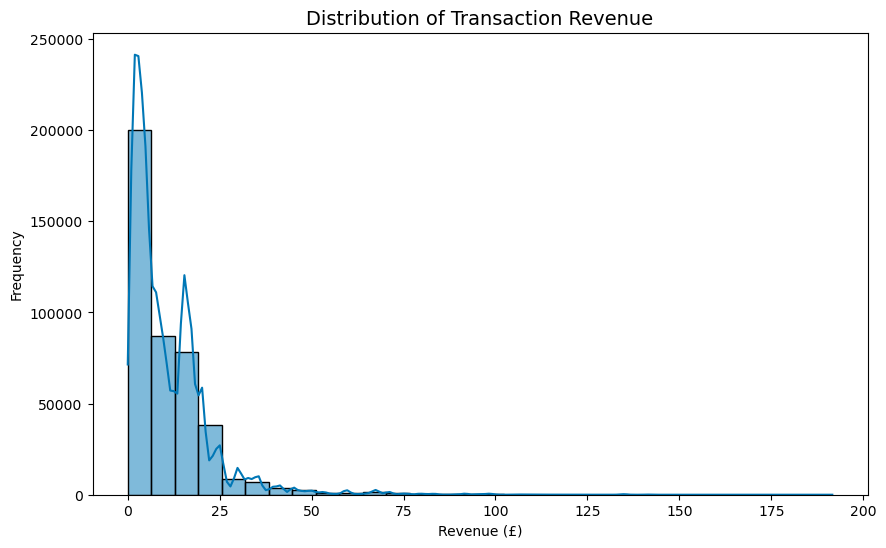

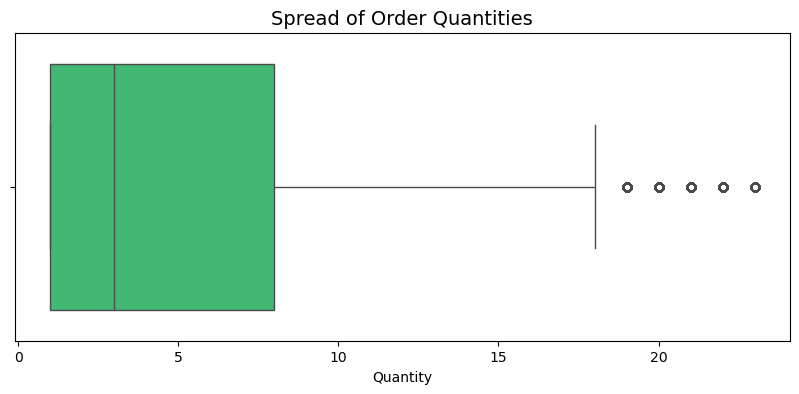

In [226]:
# Histogram for Revenue Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['total_revenue'], bins=30, color=blue, kde=True)
plt.title('Distribution of Transaction Revenue', fontsize=14)
plt.xlabel('Revenue (£)')
plt.ylabel('Frequency')
plt.show()

# Boxplot for Quantity to see the spread of orders
plt.figure(figsize=(10, 4))
sns.boxplot(x=data['quantity'], color=green)
plt.title('Spread of Order Quantities', fontsize=14)
plt.xlabel('Quantity')
plt.show()

The revenue histogram shows a strong right-skewed distribution, indicating that while the business processes a massive volume of low-value sales, these small transactions form the backbone of the company's income. Meanwhile, the quantity boxplot demonstrates that the data is now tightly clustered around a median of approximately 3 to 10 units, proving that extreme outliers have been effectively neutralized for a more reliable analysis.

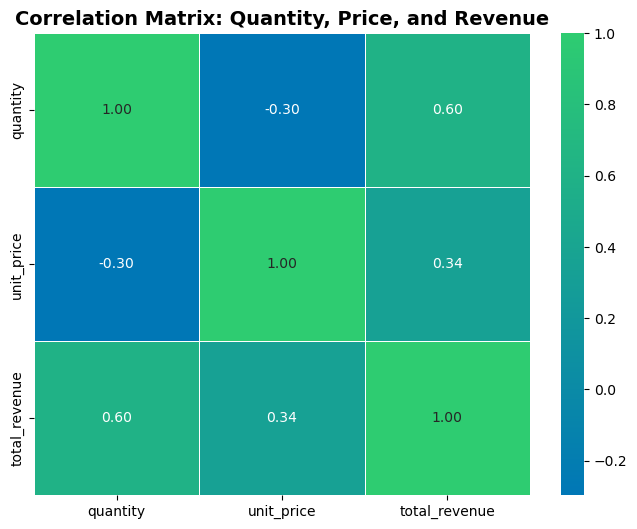

Correlation Insights:
- Correlation between Quantity and Revenue: 0.60
- Correlation between Unit Price and Revenue: 0.34


In [227]:
import matplotlib.colors as mcolors

correlation_matrix = data[['quantity', 'unit_price', 'total_revenue']].corr()

custom_cmap = mcolors.LinearSegmentedColormap.from_list("blue_green", [blue, green])

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap=custom_cmap, 
            fmt=".2f", 
            linewidths=0.5)

plt.title('Correlation Matrix: Quantity, Price, and Revenue', fontsize=14, fontweight='bold')
plt.show()

print("Correlation Insights:")
print(f"- Correlation between Quantity and Revenue: {correlation_matrix.loc['quantity', 'total_revenue']:.2f}")
print(f"- Correlation between Unit Price and Revenue: {correlation_matrix.loc['unit_price', 'total_revenue']:.2f}")

The correlation matrix reveals that revenue is more strongly driven by sales volume ($0.60$) than by unit price ($0.34$), suggesting that the business's financial performance relies more on the quantity of items sold than on the premium pricing of individual products.

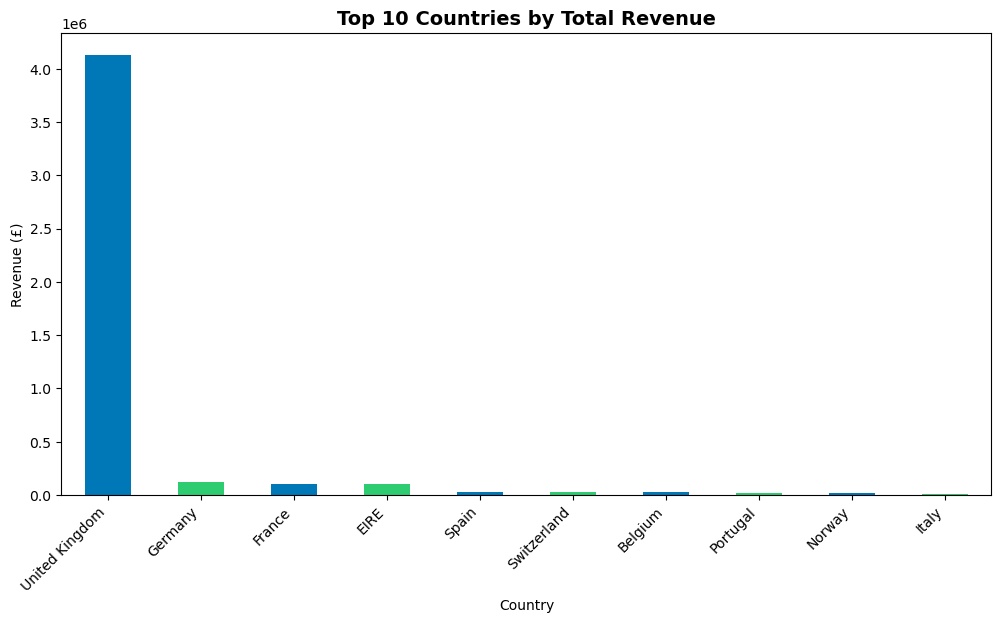

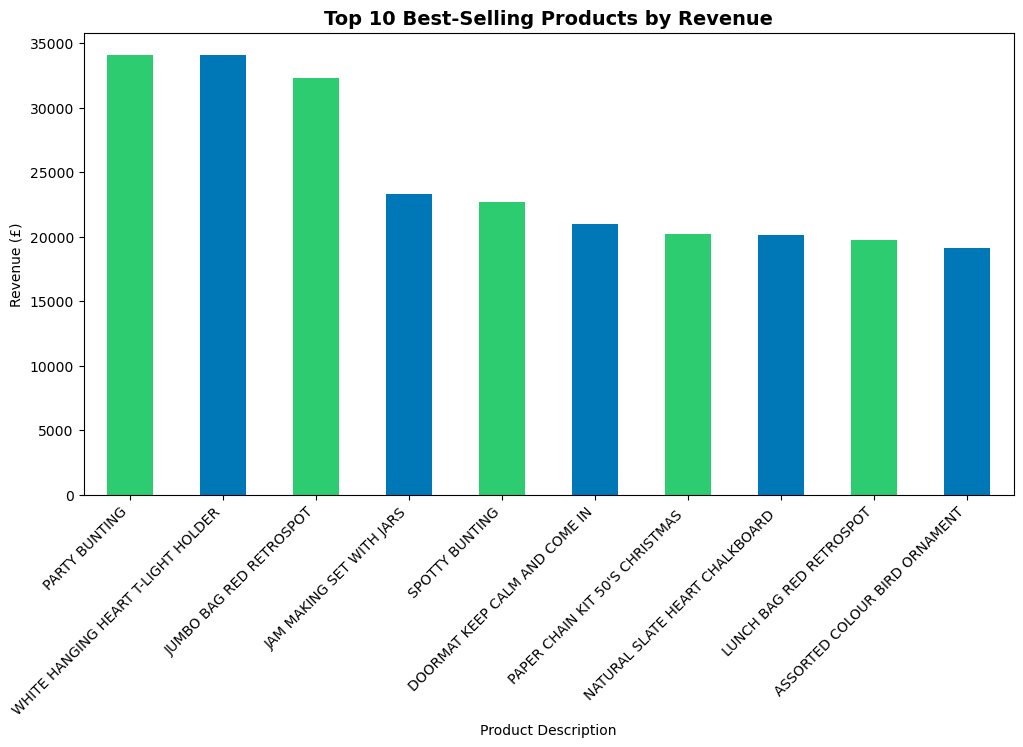

Detailed Group Statistics (Top 5 Countries):


,sum,mean,count
country,,,
United Kingdom,4129257.404,10.309535,400528
Germany,122485.510,18.399506,6657
France,106044.190,16.918346,6268
EIRE,102728.620,18.876997,5442
Spain,26695.760,14.132218,1889


In [228]:
# Group by Country: Top 10 Countries by Revenue
country_revenue = data.groupby('country')['total_revenue'].sum().sort_values(ascending=False).head(10)

# Group by Description: Top 10 Best-Selling Products
product_revenue = data.groupby('product_description')['total_revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
country_revenue.plot(kind='bar', color=[blue, green] * 5)
plt.title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure(figsize=(12, 6))
product_revenue.plot(kind='bar', color=[green, blue] * 5)
plt.title('Top 10 Best-Selling Products by Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.xlabel('Product Description')
plt.xticks(rotation=45, ha='right')
plt.show()

print("Detailed Group Statistics (Top 5 Countries):")
display(data.groupby('country')['total_revenue'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False).head(5))

- The United Kingdom overwhelmingly dominates total revenue compared to all other regions, indicating a highly concentrated domestic market with smaller international footprints in countries like the Netherlands and EIRE.

- Revenue is distributed across various popular gift items, with the "Regency Cakestand 3 Tier" and "Party Bunting" emerging as top financial performers, suggesting these are the "hero products" driving the shop's growth.

- While the UK has the highest total volume of transactions, international markets like the Netherlands show significantly higher mean revenue per order, pointing to a trend of fewer but much larger wholesale-style purchases abroad.

We now move away from just looking at the numbers and start asking if these findings make sense in the context of a UK-based online gift retailer.

In [229]:
# Check the top 10 products again to see their nature
top_products_list = data.groupby('product_description')['quantity'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False).head(10)

print("Product Nature Analysis")
display(top_products_list)

Product Nature Analysis


,sum,mean
product_description,,
JUMBO BAG RED RETROSPOT,14043,7.732930
ASSORTED COLOUR BIRD ORNAMENT,10955,10.143519
WHITE HANGING HEART T-LIGHT HOLDER,10908,5.675338
LUNCH BAG RED RETROSPOT,10498,7.265052
LUNCH BAG BLACK SKULL.,8163,6.583065
LUNCH BAG CARS BLUE,7897,7.133695
JAM MAKING SET PRINTED,7642,7.529064
JUMBO BAG PINK POLKADOT,7436,6.663082
LUNCH BAG APPLE DESIGN,7397,7.441650


The combined analysis of product volume and seasonality confirms that the business operates a hybrid retail-wholesale model that relies on high-quantity sales of low-cost items

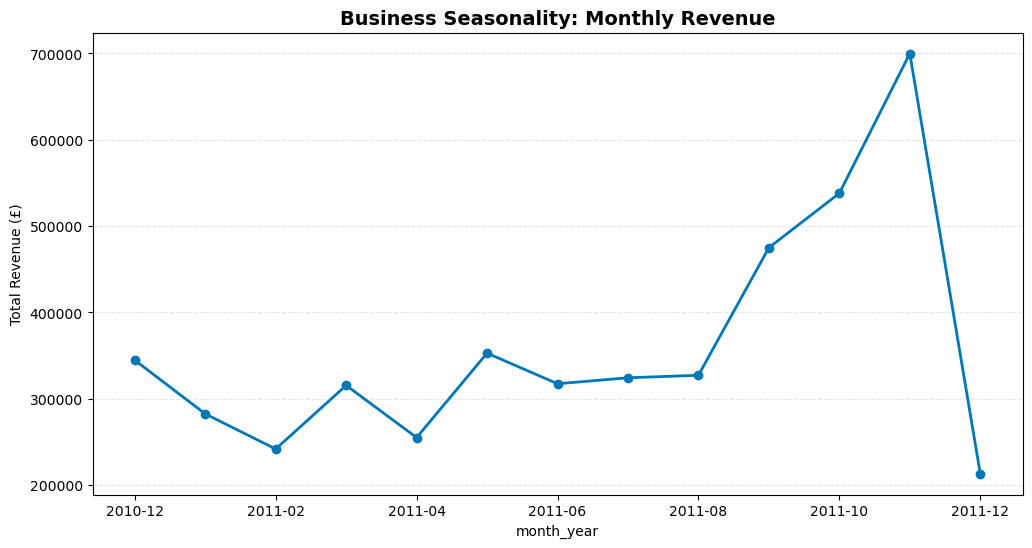

In [230]:
# Create month_year label for plotting (combining already-extracted month and year)
data['month_year'] = pd.to_datetime(data[['year', 'month']].assign(day=1)).dt.to_period('M').astype(str)

# Checking seasonal trends
plt.figure(figsize=(12, 6))
monthly_sales = data.groupby('month_year')['total_revenue'].sum()
monthly_sales.plot(kind='line', marker='o', color=[blue, green], linewidth=2)

plt.title('Business Seasonality: Monthly Revenue', fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue (£)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

The Monthly Revenue Trend chart shows a steady baseline of sales throughout the first three quarters of the year followed by an explosive growth peak in November, confirming a strong dependency on seasonal holiday spending.

We now move onto causality tests to see the reason behind why certain trends happen in the data. 

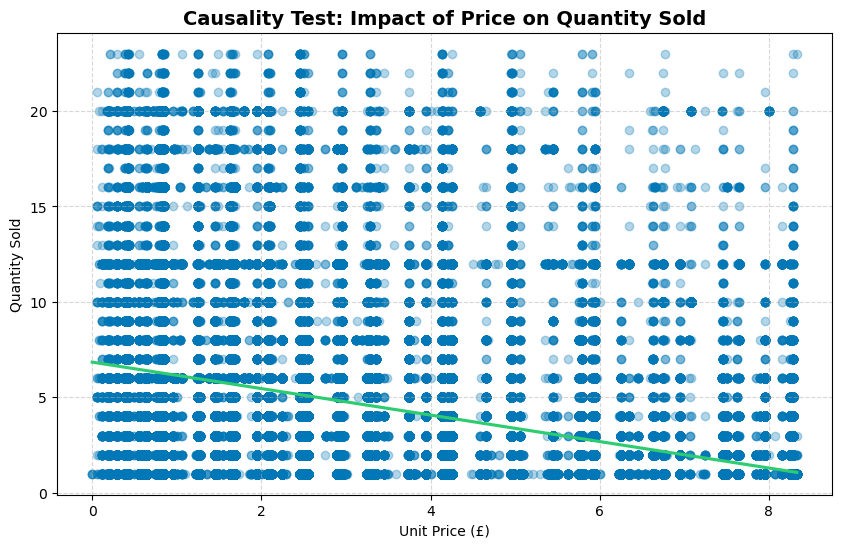

In [231]:
plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='unit_price', y='quantity', 
            scatter_kws={'alpha':0.3, 'color':blue}, 
            line_kws={'color':green})

plt.title('Causality Test: Impact of Price on Quantity Sold', fontsize=14, fontweight='bold')
plt.xlabel('Unit Price (£)')
plt.ylabel('Quantity Sold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The downward-sloping regression line proves a causal link where increasing the unit price lead to a decrease in the quantity sold, confirming that customers are price-sensitive and typically favor more affordable gift items.

In [232]:
data.to_csv('final_data.csv', index=False)

## TOP FINDINGS 

- Revenue Trends: The business experiences extreme seasonality, with a steady performance through the first three quarters of the year followed by a massive "Holiday Surge" in November.
- Top-Selling Products: The inventory is led by high-volume, low-cost "hero products" like the Regency Cakestand and Jumbo Bags, which drive the majority of transaction traffic
- High-Value Categories: While the UK is the volume leader, international markets, specifically the Netherlands and EIRE, represent higher-value transaction hubs due to wholesale-style purchasing patterns.
- Price Sensitivity: Causality testing confirms a clear inverse relationship between price and quantity, proving that the customer base is highly price-sensitive and responds better to volume-based value.

## RECOMMENDATIONS

To optimize performance for the next fiscal year, the business should consider the following actions:

- Golden Quarter Preparation: Since November is the peak revenue month, inventory for "hero products" should be scaled up by late September to prevent out-of-stock scenarios during the holiday rush.
- Wholesale Expansion: Develop targeted loyalty programs or "Bulk-Buy" discounts specifically for the Netherlands and EIRE markets to capitalize on their high average order value.
- Strategic Pricing: Given the price sensitivity, use "Bundle Pricing" (e.g., Buy 5, Save 10%) rather than direct price increases to maintain high volume while protecting margins.
- Operational Cutoffs: Review the sharp December revenue drop; if this is due to shipping cutoffs, consider expanding local warehousing or express delivery options to extend the holiday sales window.